# Wind blown: 

In [1]:
import xarray as xr
import matplotlib.dates as dts
import matplotlib.pyplot as plt
import glob
import re
import numpy as np
from matplotlib.colors import LogNorm, Normalize
import pandas as pd
import matplotlib.dates as md

plt.rcParams["font.family"] = 'monospace'

In [2]:
def get_digits(string_with_digits, digit_order=0):
    digit = re.findall(r'\d+', string_with_digits)[digit_order]
    return digit

In [3]:
load_path = r'C:\Users\Dell\Documents\NAIS_work'
load_path = r'C:\Users\Dell\Documents\AR_2025\Analysis\Bounds'

boundary_data = 'bad_data_bounds.nc'
combined_data = "combined_nais_dataset.nc"

snow_bound_files = glob.glob(load_path+'\\select_bonds\\snow_bounds\\*')
snow_bound_files = glob.glob(load_path+'\\snow_bounds\\*')
print(get_digits(snow_bound_files[0])) #test just year

2025


In [ ]:
file = snow_bound_files[0] 

file = file[-8:-3]
file = file.split('_')
year = file[0]
month = file[1]
print(year, month)

22 04


In [5]:
snow_bound = xr.open_dataset(snow_bound_files[0])

In [6]:
open_first_process_data = False

if open_first_process_data == True:
    current_dir = os.getcwd()
    print(current_dir)
    inpath_files = current_dir+"\\ZEP_processed_files"
    files = glob.glob(inpath_files+'\\*.nc')
    XR = concat_files(files)
if open_first_process_data == False:
    XR = None

In [7]:
def search_resolution(inpath_files, resolution='5T', average='mean'):
    try:
        print("searching...")
        print(inpath_files+'\\*'+str(resolution)+'*'+str(average))
        resampled_files = glob.glob(inpath_files+'\\*'+str(resolution)+'*'+str(average)+'*')[0]
    except:
        resampled_files = None       
        pass
    return resampled_files
    
def resample_XR(XR, resolution='5T', median=False, mean=True):
    if median == True:
        XR_resampled = XR.resample({'time':resolution}).median()
    if mean == True:
        XR_resampled = XR.resample({'time':resolution}).mean()
    return XR_resampled
           
def resample_or_load(inpath_files, XR, resolution='5T', search=True,
                     savefolder=None, median=False, mean=True):                     
    if search == True:
        print("search...")
        #resolution='_'+str(resolution)
        if median == True:
            average = 'median'
        if mean == True:
            average = 'mean'
        print(average)
        file = search_resolution(inpath_files, resolution, average)
        print(file)
    if search == False:
        file = None
        
    if file:
        print("open file: "+str(file))
        XR_resampled = xr.open_dataset(file)
    if not file:
        print("resample") 
        if median == True:
            average = 'median'
        if mean == True:
            average = 'mean'  
        print(average)
        XR_resampled = resample_XR(XR, resolution, median=median, mean=mean) 
        save_xr_file(XR_resampled, inpath_files, savefolder=savefolder, 
                     filename='nais_'+str(resolution)+'_'+str(average)+'.nc')
    return XR_resampled

In [8]:
resolution='5T'
inpath_files = "C:\\Users\\Dell\\Documents\\AR_2025\\Analysis\\resampled"

inpath_files = r"C:\Users\Dell\Documents\AR_2025\Analysis\resampled"

ds = resample_or_load(inpath_files, XR=XR, resolution=resolution, search=True) #this takes awhile
print(str(ds.time.values[-1]))

search...
mean
searching...
C:\Users\Dell\Documents\AR_2025\Analysis\resampled\*5T*mean
C:\Users\Dell\Documents\AR_2025\Analysis\resampled\nais_5T_mean.nc
open file: C:\Users\Dell\Documents\AR_2025\Analysis\resampled\nais_5T_mean.nc
2024-10-05T00:00:00.000000000


In [9]:
def gen_empty_dataset(ds, var):
    dp = ds.diameter.values
    times = ds.time.values
    time = xr.DataArray(times, dims='time')
    diameters = xr.DataArray(dp, dims='diameter')
    empty_array = np.empty((len(times), len(dp)))
    empty_array[:] = np.nan
    empty = xr.DataArray(empty_array, dims=('time', 'diameter'))
    dataset_empty = xr.Dataset({var: empty}, coords={'time': time, 'diameter': diameters})
    return dataset_empty

def gen_snow_dataset(ds, bad_data, mode='ions', select_time=False, select_time_and_diameter=True):
    
    neg_ion_bounds = [
        bad_data.neg_ion_time_left.values,
        bad_data.neg_ion_time_right.values,
        bad_data.neg_ion_diam_left.values,
        bad_data.neg_ion_diam_right.values]

    pos_ion_bounds = [
        bad_data.pos_ion_time_left.values,
        bad_data.pos_ion_time_right.values,
        bad_data.pos_ion_diam_left.values,
        bad_data.pos_ion_diam_right.values]

    neg_par_bounds = [
        bad_data.neg_par_time_left.values,
        bad_data.neg_par_time_right.values,
        bad_data.neg_par_diam_left.values,
        bad_data.neg_par_diam_right.values]

    pos_par_bounds = [
        bad_data.pos_par_time_left.values,
        bad_data.pos_par_time_right.values,
        bad_data.pos_par_diam_left.values,
        bad_data.pos_par_diam_right.values]

    bad_data.close()

    ds_checked = ds.copy(deep=True)
    ds.close()

    neg_ions_checked = ds_checked.neg_ions.to_pandas()
    pos_ions_checked = ds_checked.pos_ions.to_pandas()
    neg_particles_checked = ds_checked.neg_particles.to_pandas()
    pos_particles_checked = ds_checked.pos_particles.to_pandas()

    time_num = dts.date2num(ds.time.values)
    dp = ds.diameter.values
    
    mode = 'ions'    
    ################NEG IONS##################################### 
    dataset_empty_neg_ions = gen_empty_dataset(ds, var='neg_'+str(mode))
    datasets_neg_ions_list = [dataset_empty_neg_ions]

    for i in bad_data.neg_ion_roi_id.values:
        if select_time == True:
            neg_ions_checked_ = neg_ions_checked.iloc[(time_num>=neg_ion_bounds[0][i])&(time_num<=neg_ion_bounds[1][i])]
        if select_time_and_diameter == True:
            neg_ions_checked_ = neg_ions_checked.iloc[
                (time_num>=neg_ion_bounds[0][i])&(time_num<=neg_ion_bounds[1][i]),
                (dp>=neg_ion_bounds[2][i])&(dp<=neg_ion_bounds[3][i])]

        ds_neg_ions_checked_ =  xr.DataArray(neg_ions_checked_)    
        dataset = xr.Dataset({'neg_'+str(mode): ds_neg_ions_checked_})
        datasets_neg_ions_list.append(dataset)
        
    combined_neg_ions_dataset = xr.concat(datasets_neg_ions_list, dim='time')    
    combined_neg_ions_dataset = combined_neg_ions_dataset.sortby('time')
    combined_neg_ions_dataset = combined_neg_ions_dataset.sel(time=~combined_neg_ions_dataset.get_index("time").duplicated(keep='last'))
    ################POS IONS#####################################    
    dataset_empty_pos_ions = gen_empty_dataset(ds, var='pos_'+str(mode))
    datasets_pos_ions_list = [dataset_empty_pos_ions]

    for i in bad_data.pos_ion_roi_id.values:
        if select_time == True:
            pos_ions_checked_ = pos_ions_checked.iloc[(time_num>=pos_ion_bounds[0][i])&(time_num<=pos_ion_bounds[1][i])]
        if select_time_and_diameter == True:
            pos_ions_checked_ = pos_ions_checked.iloc[
                (time_num>=pos_ion_bounds[0][i])&(time_num<=pos_ion_bounds[1][i]),
                (dp>=pos_ion_bounds[2][i])&(dp<=pos_ion_bounds[3][i])]
        
        ds_pos_ions_checked_ =  xr.DataArray(pos_ions_checked_)    
        dataset = xr.Dataset({'pos_'+str(mode): ds_pos_ions_checked_})
        datasets_pos_ions_list.append(dataset)
        
    combined_pos_ions_dataset = xr.concat(datasets_pos_ions_list, dim='time')    
    combined_pos_ions_dataset = combined_pos_ions_dataset.sortby('time')
    combined_pos_ions_dataset = combined_pos_ions_dataset.sel(time=~combined_pos_ions_dataset.get_index("time").duplicated(keep='last'))
        
    #############################################################
    
    mode = 'particles'
    ################NEG particles##################################### 
    dataset_empty_neg_particles = gen_empty_dataset(ds, var='neg_'+str(mode))
    datasets_neg_particles_list = [dataset_empty_neg_particles]

    for i in bad_data.neg_par_roi_id.values:
        if select_time == True:
            neg_particles_checked_ = neg_particles_checked.iloc[(time_num>=neg_par_bounds[0][i])&(time_num<=neg_par_bounds[1][i])]
        if select_time_and_diameter == True:
            neg_particles_checked_ = neg_particles_checked.iloc[
                (time_num>=neg_par_bounds[0][i])&(time_num<=neg_par_bounds[1][i]),
                (dp>=neg_par_bounds[2][i])&(dp<=neg_par_bounds[3][i])]

        neg_particles_checked_ =  xr.DataArray(neg_particles_checked_)    
        dataset = xr.Dataset({'neg_'+str(mode): neg_particles_checked_})
        datasets_neg_particles_list.append(dataset)
        
    combined_neg_particles_dataset = xr.concat(datasets_neg_particles_list, dim='time')    
    combined_neg_particles_dataset = combined_neg_particles_dataset.sortby('time')
    combined_neg_particles_dataset = combined_neg_particles_dataset.sel(time=~combined_neg_particles_dataset.get_index("time").duplicated(keep='last'))
        
    ################POS particles#####################################    
    dataset_empty_pos_particles = gen_empty_dataset(ds, var='pos_'+str(mode))
    datasets_pos_particles_list = [dataset_empty_pos_particles]

    for i in bad_data.pos_par_roi_id.values:
        if select_time == True:
            pos_particles_checked_ = pos_particles_checked.iloc[(time_num>=pos_par_bounds[0][i])&(time_num<=pos_par_bounds[1][i])]
        if select_time_and_diameter == True:
            pos_particles_checked_ = pos_particles_checked.iloc[
                (time_num>=pos_par_bounds[0][i])&(time_num<=pos_par_bounds[1][i]),
                (dp>=pos_par_bounds[2][i])&(dp<=pos_par_bounds[3][i])]
        
        ds_pos_particles_checked_ =  xr.DataArray(pos_particles_checked_)    
        dataset = xr.Dataset({'pos_'+str(mode): ds_pos_particles_checked_})
        datasets_pos_particles_list.append(dataset)
        
    combined_pos_particles_dataset = xr.concat(datasets_pos_particles_list, dim='time')    
    combined_pos_particles_dataset = combined_pos_particles_dataset.sortby('time')
    combined_pos_particles_dataset = combined_pos_particles_dataset.sel(time=~combined_pos_particles_dataset.get_index("time").duplicated(keep='last'))
    ########################################################################
    
    combined_dataset = xr.merge([combined_neg_ions_dataset, combined_pos_ions_dataset, 
                                 combined_neg_particles_dataset, combined_pos_particles_dataset]) 

    return combined_dataset

In [10]:
def thickax(ax, fontsize=12):
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(1.5)
    plt.rc('axes', linewidth=1.5)    
    ax = plt.gca()
    for tick in ax.xaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
    for tick in ax.yaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
    ax.tick_params(direction='out', length=7, width=1.5, pad=12, bottom=True, top=False, left=True, right=False)
	
def spectral_plot(xr_nais, var, title, x='time', fs_label=20, xlabel='Datetime', log_colour_scale=True, 
                  add_axis_labels=True,
                  add_colourbar_labels=False, vmin=10**(-1), vmax=10**5, diameters_ticks=None,
                  cbar_label=r'dN/dlogD$_\\mathrm{p}$ [$\mathrm{cm}^{-3}$]', 
                  ylabel='D$_{\mathrm{p}}$ [m]', cmap='jet', xmin=None, xmax=None, 
                  remove_xticks=False, alpha=1, ymin=None, ymax=None, DateFormat='%H:%M', ax=None): #magma
    single_plot = False
    if ax == None:
        fig, ax = plt.subplots(figsize=(25,5))
        single_plot = True
        
    if log_colour_scale == True:
        xr_nais[var] = xr.where(xr_nais[var]==0, 10**(-100), xr_nais[var])    
        im = xr_nais[var].plot(x=x, yscale='log', norm=LogNorm(vmin=vmin,vmax=vmax), cmap=cmap, 
                                        add_colorbar=False, alpha=alpha, ax=ax)
    if log_colour_scale == False:
        im = xr_nais[var].plot(x=x, yscale='log', vmin=vmin, vmax=vmax, cmap=cmap, 
                                        add_colorbar=False, alpha=alpha, ax=ax)    
    if add_axis_labels == True:
        ax.set_ylabel(ylabel, fontsize=fs_label)
        ax.set_xlabel(xlabel, fontsize=fs_label)
        ax.set_title(title, fontsize=15, loc='left')
    
    thickax(ax, fontsize=fs_label)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    
    if remove_xticks == True:
        ax.set_xticklabels([])
       
    if add_colourbar_labels == True: 
        cb = plt.colorbar(im, orientation="vertical")
        cb.set_label(label=cbar_label, size=fs_label)
        cb.ax.tick_params(labelsize=fs_label)

    if diameters_ticks is not None:       
        yticks = [x*10**(-9) for x in diameters_ticks]
        #yticks = [x for x in diameters_ticks]
        print(yticks)
        ax.set_yticks(yticks)
        print(diameters_ticks)
        ax.set_yticklabels(diameters_ticks, fontsize=10)

    if remove_xticks == False:
        ax.xaxis.set_major_formatter(md.DateFormatter(DateFormat))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=0)
        plt.xticks(fontsize=14, rotation=0)

    if remove_xticks == True:
        ax.set_xticks([])
        ax.set_xticklabels([])        

    if single_plot == True:
        plt.show()
        return fig
    if single_plot == False:
        return ax

<>:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\ipykernel_10880\3353576632.py:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ylabel='D$_{\mathrm{p}}$ [m]', cmap='jet', xmin=None, xmax=None,


In [11]:
list_files = []
for i in range(len(snow_bound_files)):
    snow_bound = xr.open_dataset(snow_bound_files[i])
    combined_dataset = gen_snow_dataset(ds, snow_bound, mode='ions', select_time=True, select_time_and_diameter=False)
    list_files.append(combined_dataset)    
ds_snow = xr.merge(list_files)

C:\Users\Dell\AppData\Local\Temp\ipykernel_10880\3943924807.py:6: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_snow = xr.merge(list_files)
C:\Users\Dell\AppData\Local\Temp\ipykernel_10880\3943924807.py:6: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_snow = xr.merge(list_files)
C:\Users\Dell\AppData\Local\Temp\ipykernel_10880\3

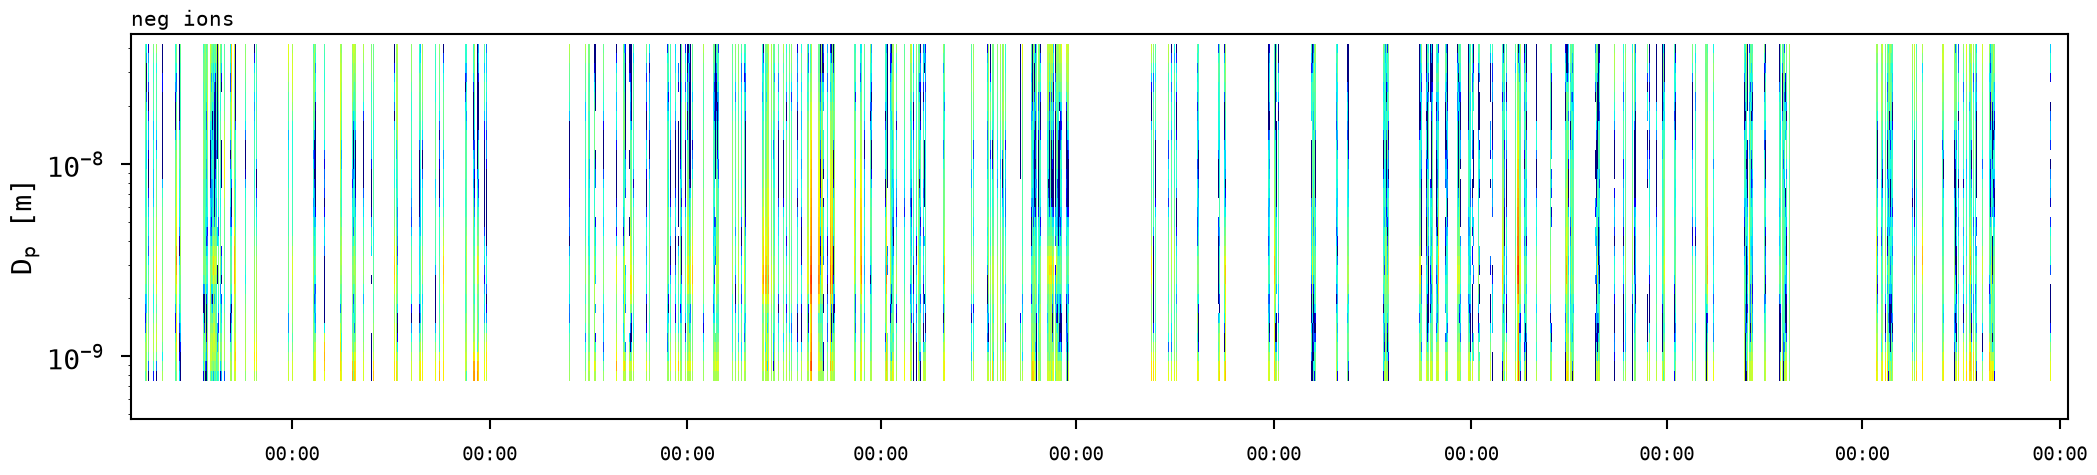

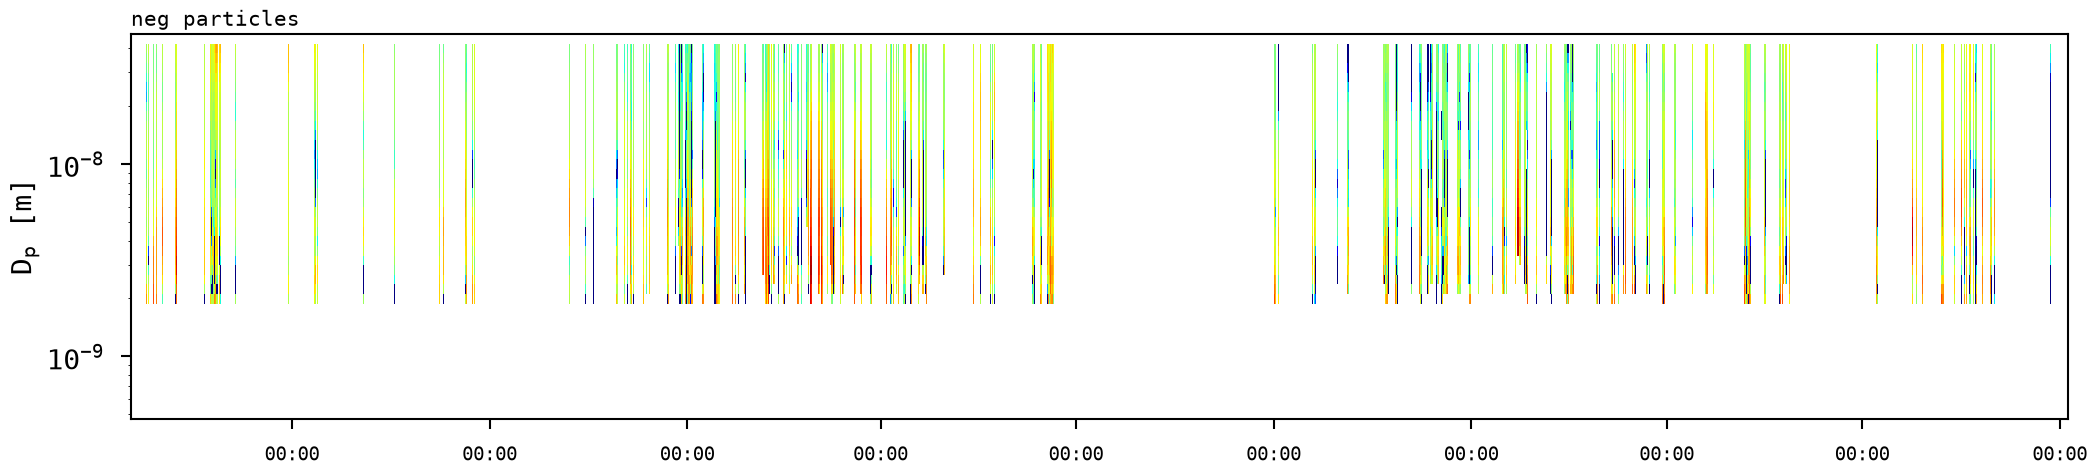

In [12]:
fig = spectral_plot(ds_snow, var='neg_ions', title='neg ions', xlabel='', ax=None)
fig = spectral_plot(ds_snow, var='neg_particles', title='neg particles', xlabel='', ax=None)

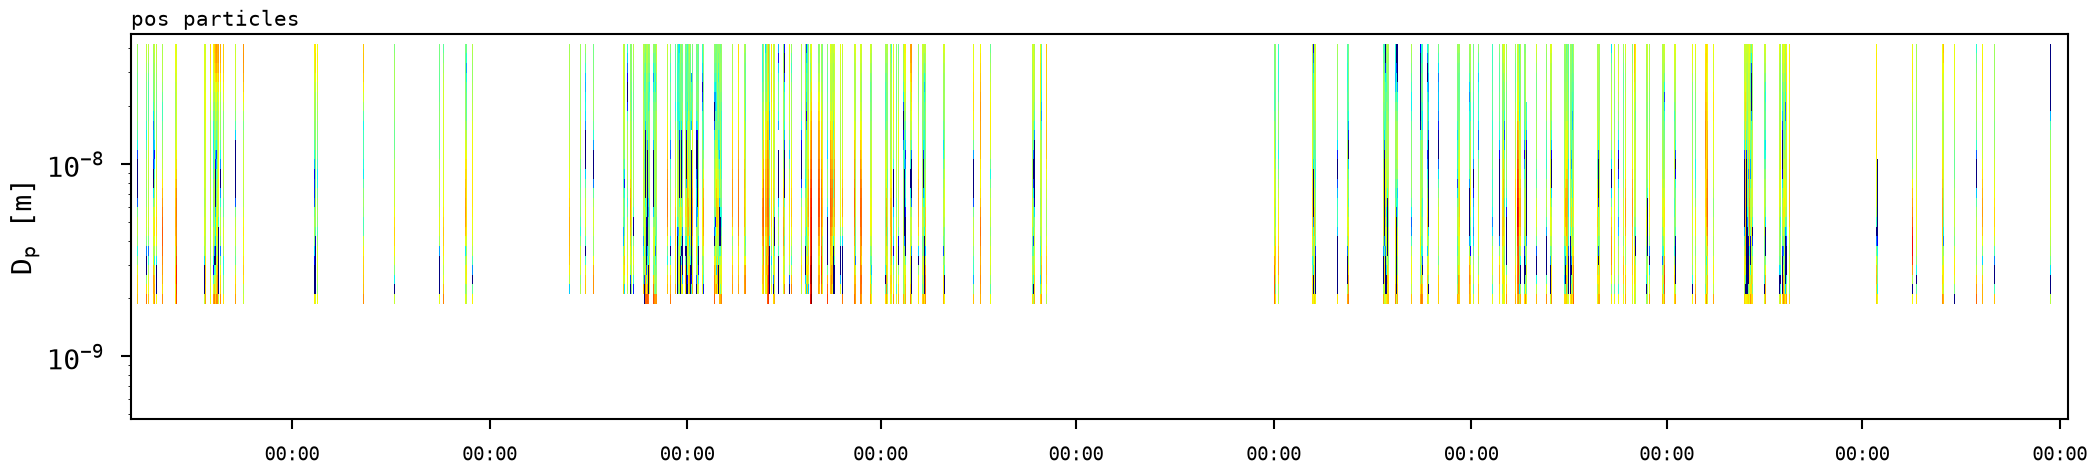

In [13]:
fig = spectral_plot(ds_snow, var='pos_particles', title='pos particles', xlabel='', ax=None)

In [14]:
def count_df(ds, var='neg_ions'):
    df_ = ds[var].to_pandas().dropna(how='all')
    df_['date'] = df_.index.date
    df_count = df_.resample('ME').count()
    df_count = df_count.max(axis=1).to_frame('5min_count')
    df_count['1hour_count'] = df_count['5min_count']*5/60
    df_count = df_count.reset_index()
    return df_count

In [15]:
df_snow_count = count_df(ds_snow)

In [16]:
df_snow_count.head(2)

,time,5min_count,1hour_count
0,2022-04-30,736,61.333333
1,2022-05-31,2739,228.250000


In [17]:
def fancy(ax, fontsize=20, spines=['top','bottom','left','right'], alpha=0.5):    
    # thickning the axes spines
    for axis in spines:
        ax.spines[axis].set_linewidth(2)
        ax.spines[axis].set_color('k')        
    # set the fontsize for all your ticks    
    for tick in ax.xaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
    for tick in ax.yaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)        
    # properties of the ticks
    ax.tick_params(direction='out', length=8, width=2, pad=10, bottom=True, top=False, left=True, right=False, color='k')    
    # add a grid to the plot
    ax.grid(True, alpha=alpha)

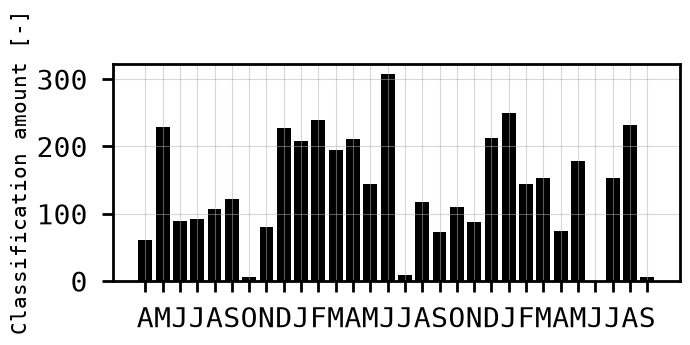

In [18]:
fig, ax = plt.subplots(figsize=(7, 3))
x = np.arange(len(df_snow_count))
ax.bar(
    x,
    df_snow_count['1hour_count'],
    color='k'
)
dates = pd.to_datetime(df_snow_count['time'])
labels = dates.dt.month.map({
    1: 'J', 2: 'F', 3: 'M', 4: 'A',
    5: 'M', 6: 'J', 7: 'J', 8: 'A',
    9: 'S', 10: 'O', 11: 'N', 12: 'D'
})
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('', fontsize=15)
ax.set_ylabel('Classification amount [-]', fontsize=15)
ax.tick_params(axis='both', labelsize=12)
fancy(ax)
plt.tight_layout()
plt.show()

In [19]:
df_count = count_df(ds)

In [20]:
df_count.head(2)

,time,5min_count,1hour_count
0,2022-04-30,3882,323.500000
1,2022-05-31,8599,716.583333


['A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D', 'J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D', 'J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O']


C:\Users\Dell\AppData\Local\Temp\ipykernel_10880\3498530964.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(letters)


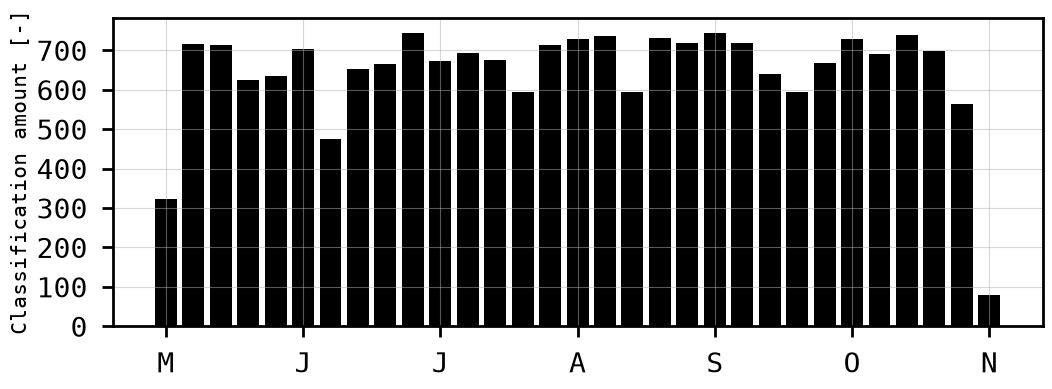

In [21]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(
    np.arange(len(df_count)),
    df_count['1hour_count'],
    color='k'
)
months = df_count['time'].values
months = [int(pd.to_datetime(x).month) for x in months]
dict_month_num_to_month_ab = dict(zip(np.arange(1,13,1), 
                    ['J','F','M','A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']))
letters = [dict_month_num_to_month_ab[x] for x in months]
print(letters)
ax.set_xticklabels(letters)
ax.set_xlabel('', fontsize=15)
ax.tick_params(labelsize=12, axis='both', which='major')
ax.tick_params(labelsize=12, axis='both', which='minor')
ax.set_ylabel('Classification amount [-]', fontsize=15)  
fancy(ax)
fig = ax.get_figure()
plt.show()

In [22]:
df_snow_count.head(2)

,time,5min_count,1hour_count
0,2022-04-30,736,61.333333
1,2022-05-31,2739,228.250000


In [23]:
df_snow_count_norm = df_snow_count['1hour_count']/df_count['1hour_count']
df_snow_count_norm = df_snow_count_norm.to_frame()
df_snow_count_norm['time'] = df_count['time']

In [24]:
def plot_bar_counts(df_count, ylabel='Windblown percentage [-]'):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(np.arange(len(df_count)), df_count['1hour_count'], color='k')
    months = df_count['time'].values
    months = [int(pd.to_datetime(x).month) for x in months]
    dict_month_num_to_month_ab = dict(zip(np.arange(1,13,1), 
                        ['J','F','M','A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']))
    letters = [dict_month_num_to_month_ab[x] for x in months]
    ax.set_xticklabels(letters)
    ax.set_xlabel('', fontsize=15)
    ax.tick_params(labelsize=12, axis='both', which='major')
    ax.tick_params(labelsize=12, axis='both', which='minor')
    ax.set_ylabel(ylabel, fontsize=15)  
    #ax.get_legend().remove()
    fancy(ax)
    fig = ax.get_figure()
    plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_10880\2838265585.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(letters)


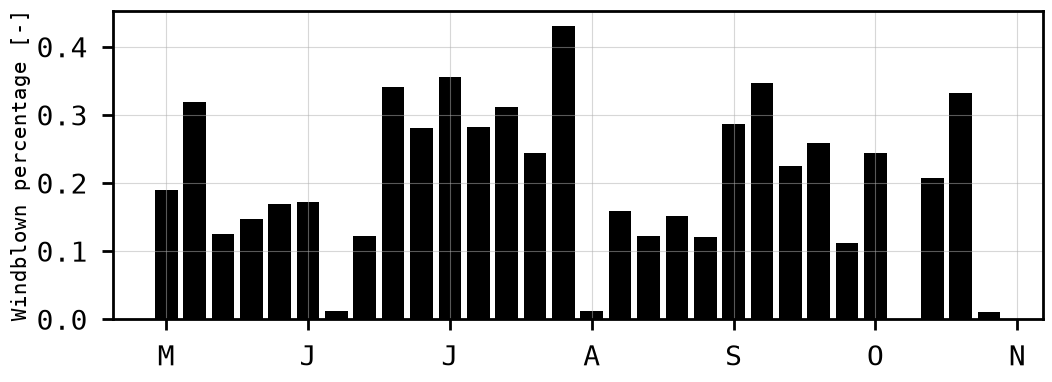

In [25]:
plot_bar_counts(df_snow_count_norm)

# Clouds: 

In [26]:
def remove_bad_data(ds, bad_data, select_time=False, select_time_and_diameter=True):
    """
    Set bad data to NaNs

    Parameters
    ----------
    ds : xarray.Dataset
        NAIS datafile
    bad_data : xarray.Dataset
        user-determined bad data boundaries using the `NaisChecker()`

    Returns
    -------
    xarray.Dataset
        Dataset with possible bad data set to `NaN`
    """

    neg_ion_bounds = [
        bad_data.neg_ion_time_left.values,
        bad_data.neg_ion_time_right.values,
        bad_data.neg_ion_diam_left.values,
        bad_data.neg_ion_diam_right.values]

    pos_ion_bounds = [
        bad_data.pos_ion_time_left.values,
        bad_data.pos_ion_time_right.values,
        bad_data.pos_ion_diam_left.values,
        bad_data.pos_ion_diam_right.values]

    neg_par_bounds = [
        bad_data.neg_par_time_left.values,
        bad_data.neg_par_time_right.values,
        bad_data.neg_par_diam_left.values,
        bad_data.neg_par_diam_right.values]

    pos_par_bounds = [
        bad_data.pos_par_time_left.values,
        bad_data.pos_par_time_right.values,
        bad_data.pos_par_diam_left.values,
        bad_data.pos_par_diam_right.values]

    bad_data.close()

    ds_checked = ds.copy(deep=True)
    ds.close()
    
    neg_ions_checked = ds_checked.neg_ions.to_pandas()
    pos_ions_checked = ds_checked.pos_ions.to_pandas()
    neg_particles_checked = ds_checked.neg_particles.to_pandas()
    pos_particles_checked = ds_checked.pos_particles.to_pandas()
    
    time_num = dts.date2num(ds.time.values)
    dp = ds.diameter.values
    
    for i in bad_data.neg_ion_roi_id.values:
        if select_time == True:
            neg_ions_checked.iloc[(time_num>=neg_ion_bounds[0][i])&(time_num<=neg_ion_bounds[1][i])] = np.nan
        if select_time_and_diameter == True:
            neg_ions_checked.iloc[
                (time_num>=neg_ion_bounds[0][i])&(time_num<=neg_ion_bounds[1][i]),
                (dp>=neg_ion_bounds[2][i])&(dp<=neg_ion_bounds[3][i])] = np.nan
    
    for i in bad_data.pos_ion_roi_id.values:
        if select_time == True:
            pos_ions_checked.iloc[(time_num>=pos_ion_bounds[0][i])&(time_num<=pos_ion_bounds[1][i])] = np.nan
        if select_time_and_diameter == True:
            pos_ions_checked.iloc[
                (time_num>=pos_ion_bounds[0][i])&(time_num<=pos_ion_bounds[1][i]),
                (dp>=pos_ion_bounds[2][i])&(dp<=pos_ion_bounds[3][i])] = np.nan
    
    for i in bad_data.neg_par_roi_id.values:
        if select_time == True:
            neg_particles_checked.iloc[(time_num>=neg_par_bounds[0][i])&(time_num<=neg_par_bounds[1][i])] = np.nan
        if select_time_and_diameter == True:
            neg_particles_checked.iloc[
                (time_num>=neg_par_bounds[0][i])&(time_num<=neg_par_bounds[1][i]),
                (dp>=neg_par_bounds[2][i])&(dp<=neg_par_bounds[3][i])] = np.nan
    
    for i in bad_data.pos_par_roi_id.values:
        if select_time == True:
            pos_particles_checked.iloc[(time_num>=pos_par_bounds[0][i])&(time_num<=pos_par_bounds[1][i])] = np.nan
        if select_time_and_diameter == True:  
            pos_particles_checked.iloc[
                (time_num>=pos_par_bounds[0][i])&(time_num<=pos_par_bounds[1][i]),
                (dp>=pos_par_bounds[2][i])&(dp<=pos_par_bounds[3][i])] = np.nan
    
    ds_checked.assign(neg_ions=(("time","diameter"),neg_ions_checked.values))
    ds_checked.assign(pos_ions=(("time","diameter"),pos_ions_checked.values))
    ds_checked.assign(neg_particles=(("time","diameter"),neg_particles_checked.values))
    ds_checked.assign(pos_particles=(("time","diameter"),pos_particles_checked.values))    
    return ds_checked

def remove_data_using_bounds(ds, bound_files, select_time=False, select_time_and_diameter=True):
    list_files = []
    print("bound files: "+str(len(list_files)))
    for i in range(len(bound_files)):
        xr_bound = xr.open_dataset(bound_files[i])
        if i == 0:
            combined_dataset = remove_bad_data(ds, xr_bound, select_time=select_time, 
                                               select_time_and_diameter=select_time_and_diameter)
        if i > 0:
            combined_dataset = remove_bad_data(combined_dataset, xr_bound, select_time=select_time, 
                                               select_time_and_diameter=select_time_and_diameter)
    return combined_dataset

search...
mean
searching...
C:\Users\Dell\Documents\AR_2025\Analysis\resampled\*5T*mean
C:\Users\Dell\Documents\AR_2025\Analysis\resampled\nais_5T_mean.nc
open file: C:\Users\Dell\Documents\AR_2025\Analysis\resampled\nais_5T_mean.nc
C:\Users\Dell\Documents\AR_2025\Analysis\Bounds\rain_cloud_bounds\rain_cloud_bounds_2022_04.nc
bound files: 0
0
<xarray.Dataset> Size: 440B
Dimensions:             (neg_ion_roi_id: 0, pos_ion_roi_id: 0,
                         neg_par_roi_id: 6, pos_par_roi_id: 5)
Coordinates:
  * neg_ion_roi_id      (neg_ion_roi_id) int64 0B 
  * pos_ion_roi_id      (pos_ion_roi_id) int64 0B 
  * neg_par_roi_id      (neg_par_roi_id) int64 48B 0 1 2 3 4 5
  * pos_par_roi_id      (pos_par_roi_id) int64 40B 0 1 2 3 4
Data variables: (12/16)
    neg_ion_time_left   (neg_ion_roi_id) float64 0B ...
    neg_ion_time_right  (neg_ion_roi_id) float64 0B ...
    neg_ion_diam_left   (neg_ion_roi_id) float64 0B ...
    neg_ion_diam_right  (neg_ion_roi_id) float64 0B ...
    pos_ion_ti

C:\Users\Dell\AppData\Local\Temp\ipykernel_10880\1698211916.py:18: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_cloud = xr.merge(list_files)
C:\Users\Dell\AppData\Local\Temp\ipykernel_10880\1698211916.py:18: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_cloud = xr.merge(list_files)
C:\Users\Dell\AppData\Local\Temp\ipykernel_108

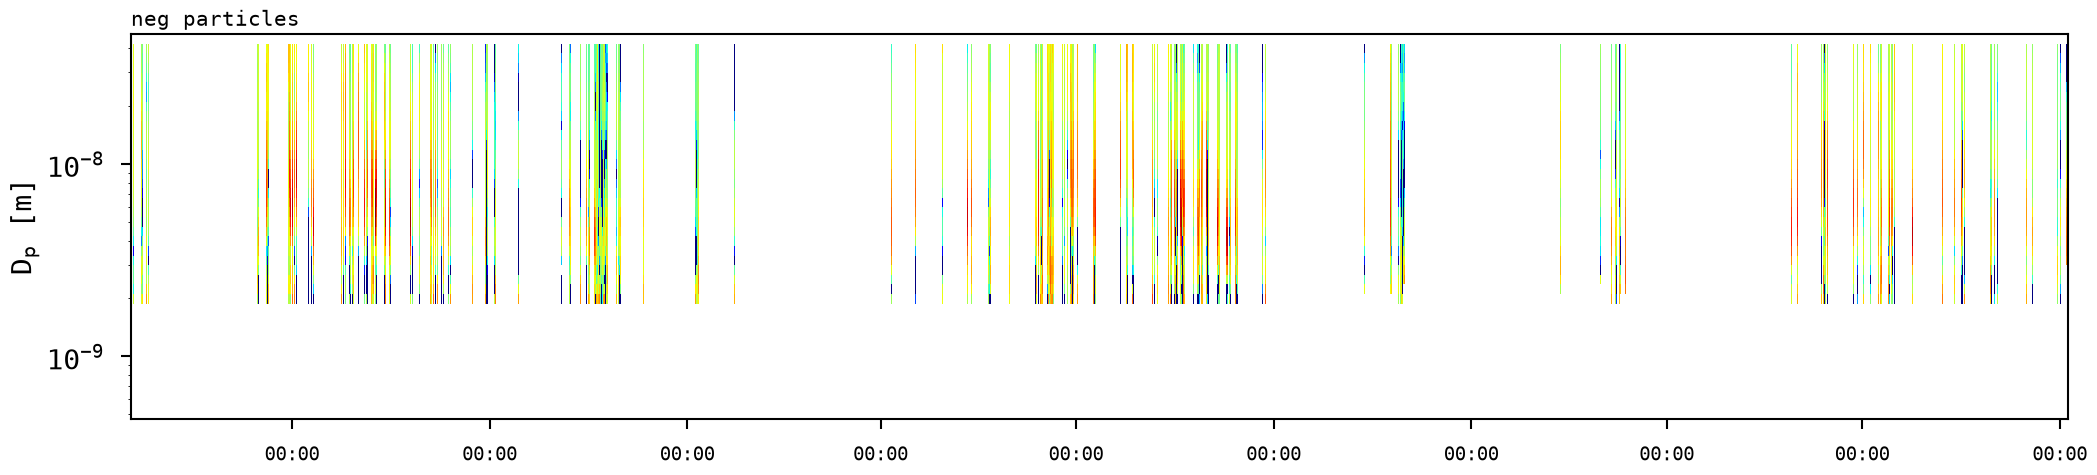

In [27]:
ds = resample_or_load(inpath_files, XR=None, resolution=resolution, search=True) #this takes awhile

rain_cloud_bound_files = glob.glob(load_path+'\\select_bonds\\rain_cloud_bounds\\*')
rain_cloud_bound_files = glob.glob(load_path+'\\rain_cloud_bounds\\*')
print(rain_cloud_bound_files[0])

ds_removed_rain_cloud = remove_data_using_bounds(ds, rain_cloud_bound_files, select_time=False, select_time_and_diameter=True)

list_files = []
for i in range(len(rain_cloud_bound_files)):
    print(i)
    rain_cloud_bound = xr.open_dataset(rain_cloud_bound_files[i])
    print(rain_cloud_bound)
    combined_dataset = gen_snow_dataset(ds, rain_cloud_bound, mode='particles', 
                                        select_time=True, select_time_and_diameter=False)
    list_files.append(combined_dataset)
    
ds_cloud = xr.merge(list_files)

fig = spectral_plot(ds_cloud, var='neg_particles', title='neg particles', xlabel='', ax=None)

In [28]:
df_cloud_count = count_df(ds_cloud, var='neg_particles')
df_cloud_count_norm = df_cloud_count['1hour_count']/df_count['1hour_count']
df_cloud_count_norm = df_cloud_count_norm.to_frame()
df_cloud_count_norm['time'] = df_count['time']

C:\Users\Dell\AppData\Local\Temp\ipykernel_10880\2838265585.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(letters)


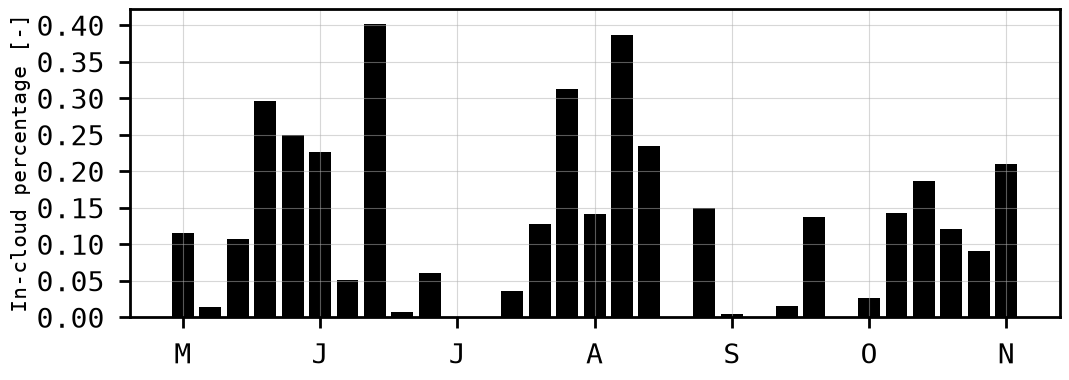

In [29]:
plot_bar_counts(df_cloud_count_norm, ylabel='In-cloud percentage [-]')

In [30]:
df_cloud_count_norm_ = df_cloud_count_norm.set_index('time')
df_cloud_count_norm_ = df_cloud_count_norm_.rename(columns={'1hour_count':'cloud_percentage'})

df_snow_count_norm_ = df_snow_count_norm.set_index('time')
df_snow_count_norm_ = df_snow_count_norm_.rename(columns={'1hour_count':'snow_percentage'})

In [31]:
df_snow_cloud_count_norm = df_snow_count_norm_.merge(df_cloud_count_norm_, left_index=True, right_index=True, how='outer')

In [32]:
df_snow_cloud_count_norm.head(2)

,snow_percentage,cloud_percentage
time,,
2022-04-30,0.189593,0.114889
2022-05-31,0.318525,0.014188


In [33]:
# Assuming df_count is your DataFrame with 'time', '1hour_count', and 'snow' columns

def plot_stacked_bar_counts(df_count, ylabel='Windblown percentage [-]'):
    # Plotting the stacked bar chart
    df_count['time'] = df_count.index
    ax = df_count.plot(x='time', y=['snow_percentage', 'cloud_percentage'], kind='bar', 
                       figsize=(12, 5), stacked=True, color=['k', 'b'])
    # Extracting the month from the 'time' column
    months = df_count['time'].values
    months = [int(pd.to_datetime(x).month) for x in months]
    # Mapping month numbers to abbreviations
    dict_month_num_to_month_ab = dict(zip(np.arange(1, 13, 1), 
                                          ['J', 'F', 'M', 'A', 'M', 'J', 
                                           'J', 'A', 'S', 'O', 'N', 'D']))
    letters = [dict_month_num_to_month_ab[x] for x in months]
    # Setting x-axis labels to the month abbreviations
    ax.set_xticklabels(letters)
    ax.set_xlabel('', fontsize=30)
    ax.tick_params(labelsize=25, axis='both', which='major')
    ax.tick_params(labelsize=25, axis='both', which='minor')
    
    for tick in ax.xaxis.get_major_ticks():
        tick.label.set_fontsize(25) 
        tick.label.set_rotation('horizontal')

    # Setting the y-axis label
    ax.set_ylabel(ylabel, fontsize=20)  
    
    # Adding a legend
    ax.legend(['snow', 'cloud'], fontsize=20, frameon=False)
    plt.show()
    return fig

In [37]:
df_snow_cloud_count_norm.index.dtype

dtype('<M8[ns]')

In [40]:
df_snow_cloud_count_norm['time'].values

array(['2022-04-30T00:00:00.000000000', '2022-05-31T00:00:00.000000000',
       '2022-06-30T00:00:00.000000000', '2022-07-31T00:00:00.000000000',
       '2022-08-31T00:00:00.000000000', '2022-09-30T00:00:00.000000000',
       '2022-10-31T00:00:00.000000000', '2022-11-30T00:00:00.000000000',
       '2022-12-31T00:00:00.000000000', '2023-01-31T00:00:00.000000000',
       '2023-02-28T00:00:00.000000000', '2023-03-31T00:00:00.000000000',
       '2023-04-30T00:00:00.000000000', '2023-05-31T00:00:00.000000000',
       '2023-06-30T00:00:00.000000000', '2023-07-31T00:00:00.000000000',
       '2023-08-31T00:00:00.000000000', '2023-09-30T00:00:00.000000000',
       '2023-10-31T00:00:00.000000000', '2023-11-30T00:00:00.000000000',
       '2023-12-31T00:00:00.000000000', '2024-01-31T00:00:00.000000000',
       '2024-02-29T00:00:00.000000000', '2024-03-31T00:00:00.000000000',
       '2024-04-30T00:00:00.000000000', '2024-05-31T00:00:00.000000000',
       '2024-06-30T00:00:00.000000000', '2024-07-31

In [43]:
df_count.plot(x='time', y=['snow_percentage', 'cloud_percentage'], kind='bar', 
                       figsize=(12, 5), stacked=True, color=['k', 'b'])
plt.show()

KeyError: "None of [Index(['snow_percentage', 'cloud_percentage'], dtype='str')] are in the [columns]"

ValueError: Must supply freq for datetime value

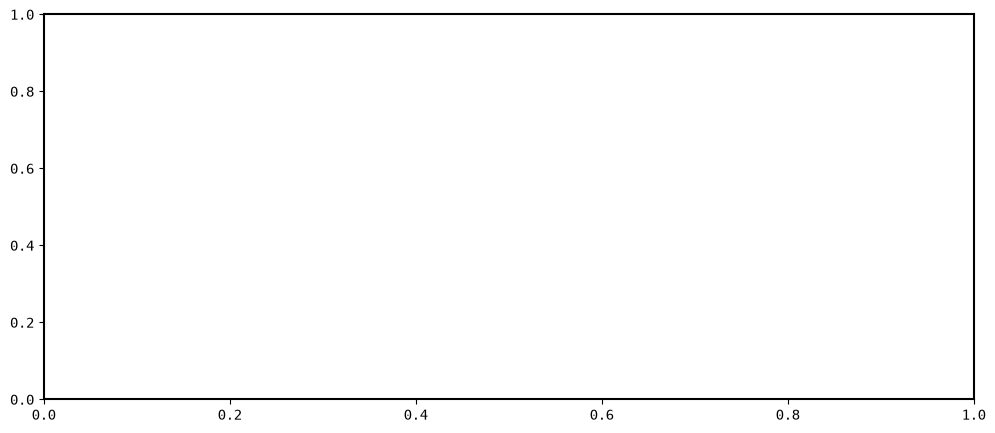

In [35]:
plot_stacked_bar_counts(df_snow_cloud_count_norm, ylabel='Percentage of artefacts [-]')

# Combined: 

In [ ]:
datetimes_5Ts = pd.date_range(start=pd.to_datetime(ds.time.values[0]), end=pd.to_datetime(ds.time.values[-1]), freq='5T',)
df_artefacts = pd.DataFrame(columns=['datetime'])
df_artefacts['datetime'] = datetimes_5Ts
df_artefacts = df_artefacts.set_index('datetime')

df_snow = ds_snow['neg_ions'].to_pandas().dropna(how='all')
df_snow['N'] = df_snow.sum(axis=1)
df_snow_N = df_snow[['N']].dropna(how='any')
df_snow_N['snow_artefact'] = 1
df_artefacts_snow = df_artefacts.merge(df_snow_N[['snow_artefact']], left_index=True, right_index=True, how='left')

df_cloud = ds_cloud['neg_particles'].to_pandas().dropna(how='all')
df_cloud['N'] = df_cloud.sum(axis=1)
df_cloud_N = df_cloud[['N']].dropna(how='any')
df_cloud_N['cloud_artefact'] = 1
df_artefacts_snow_cloud = df_artefacts_snow.merge(df_cloud_N[['cloud_artefact']], left_index=True, right_index=True, how='left')

In [ ]:
df_artefacts_snow_cloud = df_artefacts_snow_cloud.replace(np.nan, 0)

In [ ]:
df_artefacts_snow_cloud['both'] = df_artefacts_snow_cloud['snow_artefact']+df_artefacts_snow_cloud['cloud_artefact']

In [ ]:
df_artefacts_snow_cloud['both'] = df_artefacts_snow_cloud['both'].replace(1, 0)
df_artefacts_snow_cloud['both'] = df_artefacts_snow_cloud['both'].replace(2, 1)

In [ ]:
only_snow = df_artefacts_snow_cloud[(df_artefacts_snow_cloud['snow_artefact'] == 1)]
snow = df_artefacts_snow_cloud[(df_artefacts_snow_cloud['snow_artefact'] == 1) & (df_artefacts_snow_cloud['both'] != 1)]

only_cloud = df_artefacts_snow_cloud[(df_artefacts_snow_cloud['cloud_artefact'] == 1)]
cloud = df_artefacts_snow_cloud[(df_artefacts_snow_cloud['cloud_artefact'] == 1) & (df_artefacts_snow_cloud['both'] != 1)]

both = df_artefacts_snow_cloud[(df_artefacts_snow_cloud['cloud_artefact'] == 1) & (df_artefacts_snow_cloud['snow_artefact'] == 1)]

In [ ]:
print(len(snow)/len(df_artefacts_snow_cloud)*100)
print(len(only_snow)/len(df_artefacts_snow_cloud)*100)

16.175796933523753
19.027858509413846


In [ ]:
print(len(cloud)/len(df_artefacts_snow_cloud)*100)
print(len(only_cloud)/len(df_artefacts_snow_cloud)*100)

8.215122970855772
11.067184546745864


In [ ]:
len(both)/len(df_artefacts_snow_cloud)*100

2.8520615758900902

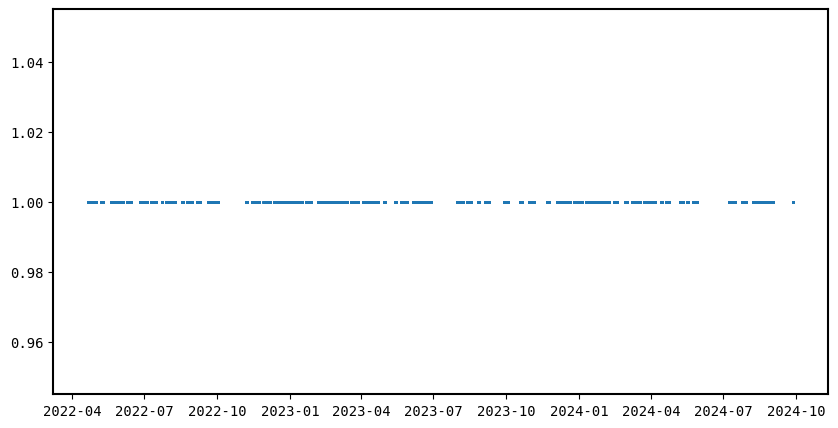

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

snow_artefacts_time = only_snow['snow_artefact'].index
snow_artefacts = only_snow['snow_artefact'].values

ax.plot(snow_artefacts_time, snow_artefacts, 'o', ms=1)

plt.show()

In [ ]:
all_M = df_artefacts_snow_cloud['snow_artefact'].resample('M').count().to_frame('all')
snow_M = df_artefacts_snow_cloud[(df_artefacts_snow_cloud['snow_artefact'] == 1) & (df_artefacts_snow_cloud['both'] != 1)].resample('M').count()['snow_artefact'].to_frame('snow_artefact')
cloud_M = df_artefacts_snow_cloud[(df_artefacts_snow_cloud['cloud_artefact'] == 1) & (df_artefacts_snow_cloud['both'] != 1)].resample('M').count()['cloud_artefact'].to_frame('cloud_artefact')
both_M = df_artefacts_snow_cloud[(df_artefacts_snow_cloud['cloud_artefact'] == 1) & (df_artefacts_snow_cloud['snow_artefact'] == 1)].resample('M').count()['both'].to_frame('both')

In [ ]:
df_artefacts_snow_cloud

,snow_artefact,cloud_artefact,both
datetime,,,
2022-04-17 00:00:00,0.0,0.0,0.0
2022-04-17 00:05:00,0.0,0.0,0.0
2022-04-17 00:10:00,0.0,0.0,0.0
2022-04-17 00:15:00,0.0,0.0,0.0
2022-04-17 00:20:00,0.0,0.0,0.0
...,...,...,...
2024-10-04 23:40:00,0.0,0.0,0.0
2024-10-04 23:45:00,0.0,0.0,0.0
2024-10-04 23:50:00,0.0,0.0,0.0


In [ ]:
month_count = all_M.merge(snow_M, left_index=True, right_index=True, how='left')
month_count = month_count.merge(cloud_M, left_index=True, right_index=True, how='left')
month_count = month_count.merge(both_M, left_index=True, right_index=True, how='left')

In [ ]:
month_count

,all,snow_artefact,cloud_artefact,both,time
datetime,,,,,
2022-04-30,336.000000,40.583333,16.416667,20.750000,2022-04-30
2022-05-31,744.000000,228.250000,10.166667,0.000000,2022-05-31
2022-06-30,720.000000,85.250000,72.583333,4.083333,2022-06-30
2022-07-31,744.000000,42.250000,135.083333,50.083333,2022-07-31
2022-08-31,744.000000,76.833333,127.750000,30.833333,2022-08-31
2022-09-30,720.000000,87.916667,126.000000,33.333333,2022-09-30
2022-10-31,744.000000,1.250000,19.750000,4.666667,2022-10-31
2022-11-30,720.000000,37.833333,192.583333,42.166667,2022-11-30
2022-12-31,744.000000,223.916667,2.166667,2.916667,2022-12-31


In [ ]:
month_count = month_count/12

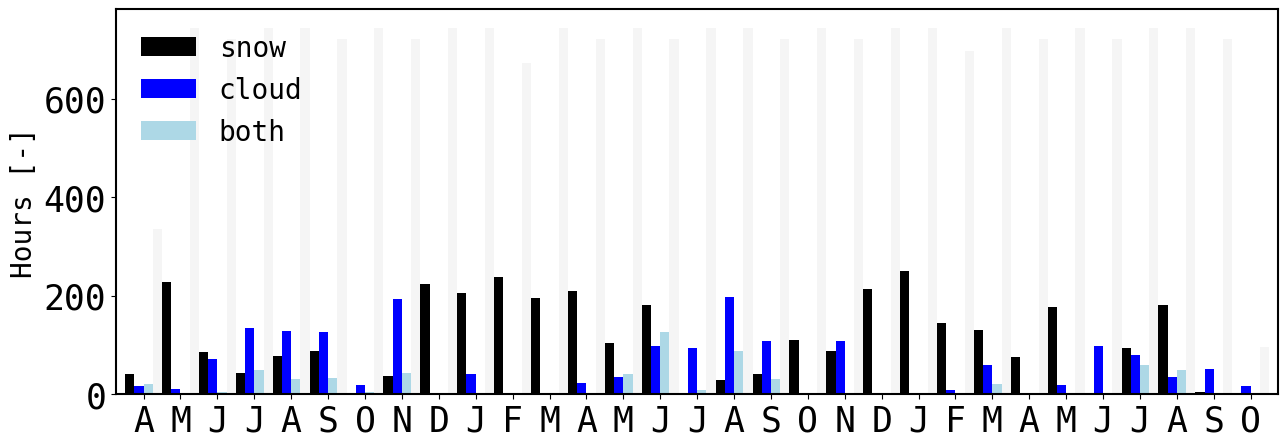

In [ ]:
def plot_stacked_bar_counts(df_count, ylabel='Windblown percentage [-]'):
    # Plotting the stacked bar chart
    df_count['time'] = df_count.index
    ax = df_count.plot(x='time', y=['snow_artefact', 'cloud_artefact', 'both', 'all'], kind='bar', 
                       figsize=(15, 5), stacked=False, width=1, color=['k', 'b', 'lightblue', 'whitesmoke'],)

    # Extracting the month from the 'time' column
    months = df_count['time'].values
    months = [int(pd.to_datetime(x).month) for x in months]

    # Mapping month numbers to abbreviations
    dict_month_num_to_month_ab = dict(zip(np.arange(1, 13, 1), 
                                          ['J', 'F', 'M', 'A', 'M', 'J', 
                                           'J', 'A', 'S', 'O', 'N', 'D']))
    letters = [dict_month_num_to_month_ab[x] for x in months]

    # Setting x-axis labels to the month abbreviations
    ax.set_xticklabels(letters)
    ax.set_xlabel('', fontsize=30)
    ax.tick_params(labelsize=25, axis='both', which='major')
    ax.tick_params(labelsize=25, axis='both', which='minor')
    
    for tick in ax.xaxis.get_major_ticks():
        tick.label.set_fontsize(25) 
        tick.label.set_rotation('horizontal')

    # Setting the y-axis label
    ax.set_ylabel(ylabel, fontsize=20)  
    
    # Adding a legend
    ax.legend(['snow', 'cloud', 'both'], fontsize=20, frameon=False)

    # Finalizing and showing the plot
    plt.show()

plot_stacked_bar_counts(month_count, ylabel='Hours [-]')